WDM Channels:
Channel 1: 1530 nm
Channel 2: 1534 nm
Channel 3: 1538 nm
Channel 4: 1542 nm
Channel 5: 1546 nm
Channel 6: 1550 nm
Channel 7: 1554 nm
Channel 8: 1558 nm


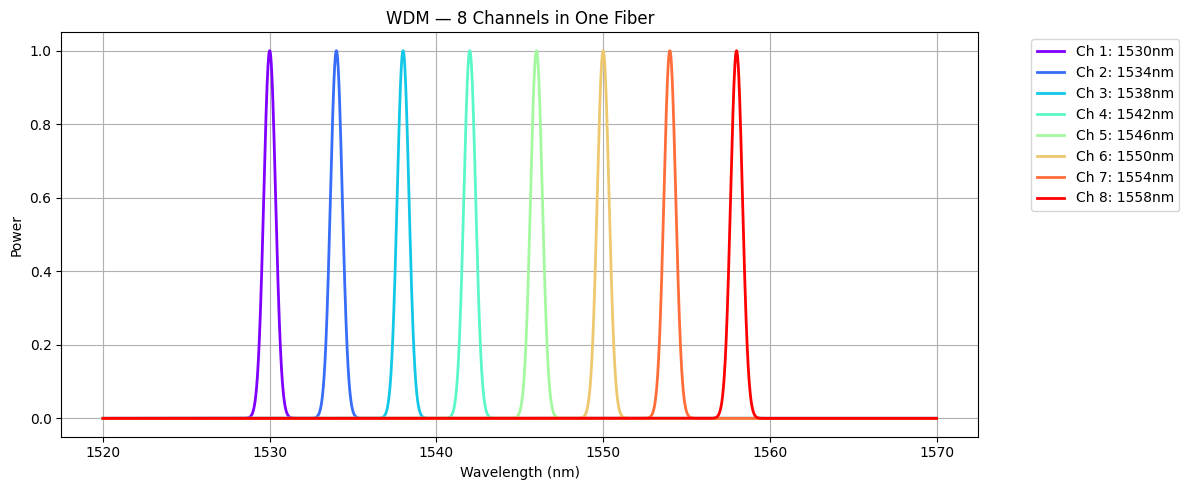

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# WDM — একসাথে অনেক channel
# প্রতিটা channel আলাদা wavelength

# 8টা channel
channels = 8
lambda_start = 1530  # nm
channel_spacing = 4  # nm

wavelengths_center = [lambda_start + i*channel_spacing 
                      for i in range(channels)]

print("WDM Channels:")
for i, wl in enumerate(wavelengths_center):
    print(f"Channel {i+1}: {wl} nm")

# প্রতিটা channel-এর spectrum
wavelength = np.linspace(1520, 1570, 10000)

plt.figure(figsize=(12, 5))

colors = plt.cm.rainbow(np.linspace(0, 1, channels))

for i, (wl_c, color) in enumerate(zip(wavelengths_center, colors)):
    # Gaussian shape — প্রতিটা channel
    power = np.exp(-((wavelength - wl_c)**2) / (0.5**2))
    plt.plot(wavelength, power, color=color, 
             linewidth=2, label=f'Ch {i+1}: {wl_c}nm')

plt.title("WDM — 8 Channels in One Fiber")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Power")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

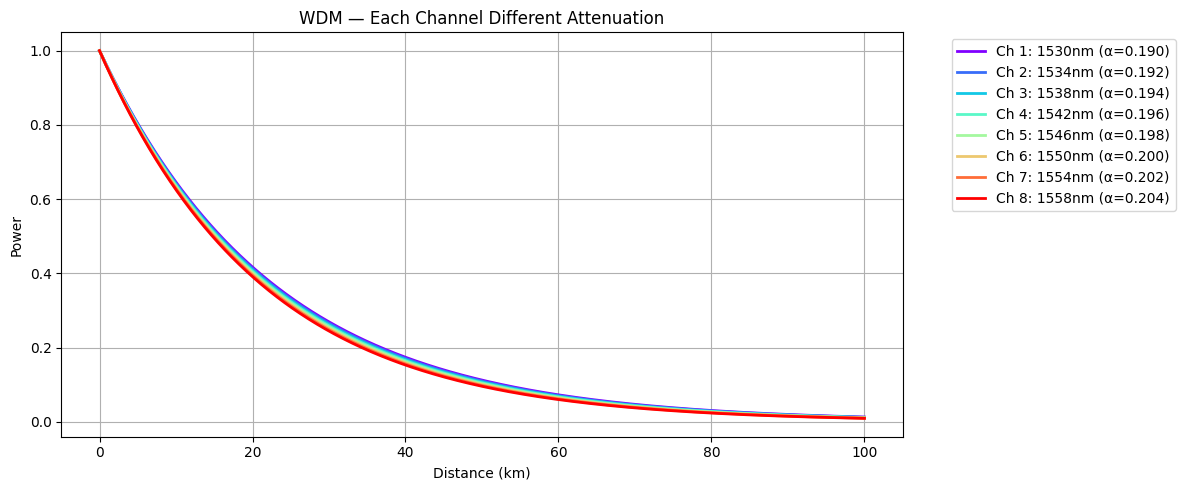

In [3]:
#attenuation সহ WDM
plt.figure(figsize=(12, 5))

for i, (wl_c, color) in enumerate(zip(wavelengths_center, colors)):
    # প্রতিটা channel-এর আলাদা attenuation
    alpha_wl = 0.2 + (wl_c - 1550) * 0.0005
    P = 10**(-alpha_wl * distance / 10)
    plt.plot(distance, P, color=color,
             linewidth=2, label=f'Ch {i+1}: {wl_c}nm (α={alpha_wl:.3f})')

plt.title("WDM — Each Channel Different Attenuation")
plt.xlabel("Distance (km)")
plt.ylabel("Power")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()